# Online Retail Sales Analysis

## Project Overview

This project performs an end-to-end analysis of an Online Retail dataset using Python.

The objective is to clean the raw transactional data, explore sales and customer behavior, identify key products and markets, analyze sales trends, and generate actionable business insights.

## Business Objectives

- Analyze overall sales performance
- Identify top-performing products
- Identify high-value customers
- Analyze country-wise revenue and order performance
- Understand monthly sales trends
- Investigate returns and unusual transactions
- Generate actionable business recommendations

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading

In [19]:
df = pd.read_csv(
    r"C:\Users\Palak Jain\OneDrive\Desktop\Online Retail.csv"
)

In [20]:
test = pd.read_csv(
    r"C:\Users\Palak Jain\OneDrive\Desktop\Online Retail.csv",
    nrows=5
)

test

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850,United Kingdom


# Data Understanding

In [21]:
df.shape

(541909, 8)

In [22]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [24]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,01-12-2010 08:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,01-12-2010 08:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,01-12-2010 08:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,01-12-2010 08:34,1.69,13047.0,United Kingdom


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


# Missing Value Analysis

In [26]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [27]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

# Duplicate Analysis

In [28]:
df.duplicated().sum()

np.int64(5268)

In [30]:
df[df.duplicated()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,01-12-2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,01-12-2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,01-12-2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,01-12-2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,01-12-2010 11:49,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,01-12-2010 11:49,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,01-12-2010 11:49,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,01-12-2010 11:49,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,01-12-2010 11:49,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,01-12-2010 11:49,3.75,17920.0,United Kingdom


In [31]:
original_rows = len(df)

df = df.drop_duplicates()

cleaned_rows = len(df)

print("Original rows:", original_rows)
print("Rows after removing duplicates:", cleaned_rows)
print("Duplicates removed:", original_rows - cleaned_rows)

Original rows: 541909
Rows after removing duplicates: 536641
Duplicates removed: 5268


# DateTime Conversion

In [33]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"],dayfirst = True)

In [34]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [35]:
df["InvoiceDate"].head()

0   2010-12-01 08:26:00
1   2010-12-01 08:26:00
2   2010-12-01 08:26:00
3   2010-12-01 08:26:00
4   2010-12-01 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

# Negative Quantity / Returns Analysis

In [36]:
df["Quantity"].min()

-80995

In [37]:
negative_qty = df[df["Quantity"] < 0]

len(negative_qty)

10587

In [38]:
negative_qty["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     9251
False    1336
Name: count, dtype: int64

In [39]:
negative_non_c = negative_qty[
    ~negative_qty["InvoiceNo"].astype(str).str.startswith("C")
]

negative_non_c.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


# Outlier Analysis

In [42]:
((df["Quantity"] < 0) & (df["UnitPrice"] == 0)).sum()

np.int64(1336)

In [43]:
sales_df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

In [44]:
sales_df.shape

(524878, 8)

# Feature Engineering

In [45]:
sales_df["Revenue"] = sales_df["Quantity"] * sales_df["UnitPrice"]

In [46]:
sales_df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [47]:
sales_df[["Quantity", "UnitPrice", "Revenue"]].describe()

,Quantity,UnitPrice,Revenue
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


In [48]:
sales_df.nlargest(10, "Quantity")[
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "Revenue"]
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40


In [49]:
sales_df.nlargest(10, "Quantity")[
    ["InvoiceNo", "CustomerID", "Country", "Description", "Quantity", "UnitPrice", "Revenue"]
]

,InvoiceNo,CustomerID,Country,Description,Quantity,UnitPrice,Revenue
540421,581483,16446.0,United Kingdom,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60
61619,541431,12346.0,United Kingdom,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60
421632,573008,12901.0,United Kingdom,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00
206121,554868,13135.0,United Kingdom,SMALL POPCORN HOLDER,4300,0.72,3096.00
97432,544612,18087.0,United Kingdom,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92
270885,560599,14609.0,United Kingdom,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16
52711,540815,15749.0,United Kingdom,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
160546,550461,15749.0,United Kingdom,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40
433788,573995,16308.0,United Kingdom,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00
4945,536830,16754.0,United Kingdom,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40


# Country Analysis

In [50]:
sales_df["Country"].nunique()

38

## Revenue

In [51]:
country_revenue = (
    sales_df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

## Orders

In [52]:
country_orders = (
    sales_df.groupby("Country")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

country_orders.head(10)

Country
United Kingdom    18019
Germany             457
France              392
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: InvoiceNo, dtype: int64

## Average Order Value (AOV) by Country

In [53]:
country_aov = (
    country_revenue / country_orders
).sort_values(ascending=False)

country_aov.head(10)

Country
Singapore      3039.898571
Netherlands    3036.663191
Australia      2429.014211
Japan          1969.282632
Lebanon        1693.880000
Hong Kong      1407.545455
Brazil         1143.600000
Sweden         1065.773056
Switzerland    1056.807407
Denmark        1053.074444
dtype: float64

#  Top Products by Revenue

In [54]:
product_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

# Product Performance Analysis

In [56]:
product_revenue = (
    sales_df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)

Description
DOTCOM POSTAGE                        206248.77
REGENCY CAKESTAND 3 TIER              174156.54
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106236.72
PARTY BUNTING                          99445.23
JUMBO BAG RED RETROSPOT                94159.81
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
POSTAGE                                78101.88
Manual                                 77752.82
RABBIT NIGHT LIGHT                     66870.03
Name: Revenue, dtype: float64

# Top Products by Quantity

In [57]:
product_quantity = (
    sales_df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity.head(10)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
POPCORN HOLDER                        36749
PACK OF 72 RETROSPOT CAKE CASES       36396
ASSORTED COLOUR BIRD ORNAMENT         36362
RABBIT NIGHT LIGHT                    30739
MINI PAINT SET VINTAGE                26633
Name: Quantity, dtype: int64

# Top Customers by Revenue

In [58]:
customer_revenue = (
    sales_df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head(10)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

# Customer Order Frequency

In [59]:
customer_orders = (
    sales_df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

customer_orders.head(10)

CustomerID
12748.0    209
14911.0    201
17841.0    124
13089.0     97
14606.0     93
15311.0     91
12971.0     86
14646.0     73
16029.0     63
13408.0     62
Name: InvoiceNo, dtype: int64

# Monthly Revenue

In [60]:
sales_df["Month"] = sales_df["InvoiceDate"].dt.to_period("M")

In [61]:
monthly_revenue = (
    sales_df.groupby("Month")["Revenue"]
    .sum()
)

monthly_revenue

Month
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: Revenue, dtype: float64

# Monthly Orders

In [62]:
monthly_orders = (
    sales_df.groupby("Month")["InvoiceNo"]
    .nunique()
)

monthly_orders

Month
2010-12    1559
2011-01    1086
2011-02    1100
2011-03    1454
2011-04    1246
2011-05    1681
2011-06    1533
2011-07    1475
2011-08    1361
2011-09    1837
2011-10    2040
2011-11    2769
2011-12     819
Freq: M, Name: InvoiceNo, dtype: int64

# Monthly AOV

In [63]:
monthly_aov = (
    monthly_revenue / monthly_orders
)

monthly_aov

Month
2010-12    526.910026
2011-01    635.185645
2011-02    475.041418
2011-03    492.582710
2011-04    430.953845
2011-05    457.642243
2011-06    496.116771
2011-07    486.831268
2011-08    556.826877
2011-09    575.087203
2011-10    564.344966
2011-11    543.108263
2011-12    778.742772
Freq: M, dtype: float64

# Return Analysis

In [64]:
returns = df[df["Quantity"] < 0].copy()

returns["ReturnedQuantity"] = returns["Quantity"].abs()

returns["ReturnedQuantity"].sum()

np.int64(482517)

# Return transactions

In [65]:
returns["InvoiceNo"].nunique()

5172

# Return rate

In [66]:
return_rate = (
    returns["InvoiceNo"].nunique()
    / df["InvoiceNo"].nunique()
    * 100
)

return_rate

19.969111969111967

# Country Revenue Contribution %

In [67]:
country_revenue_pct = (
    country_revenue / country_revenue.sum() * 100
).sort_values(ascending=False)

country_revenue_pct.head(10)

Country
United Kingdom    84.586078
Netherlands        2.682234
EIRE               2.660567
Germany            2.148807
France             1.969772
Australia          1.301000
Spain              0.578443
Switzerland        0.536243
Belgium            0.387107
Sweden             0.360528
Name: Revenue, dtype: float64

# Best & Worst Sales Months

##  highest revenue month

In [68]:
monthly_revenue.idxmax()

Period('2011-11', 'M')

## highest revenue

In [70]:
monthly_revenue.max()

1503866.78

## lowest revenue month

In [73]:
monthly_revenue.idxmin()


Period('2011-02', 'M')

## lowest revenue

In [74]:
monthly_revenue.min()

522545.56

# Visualizations

## Monthly Revenue Trend

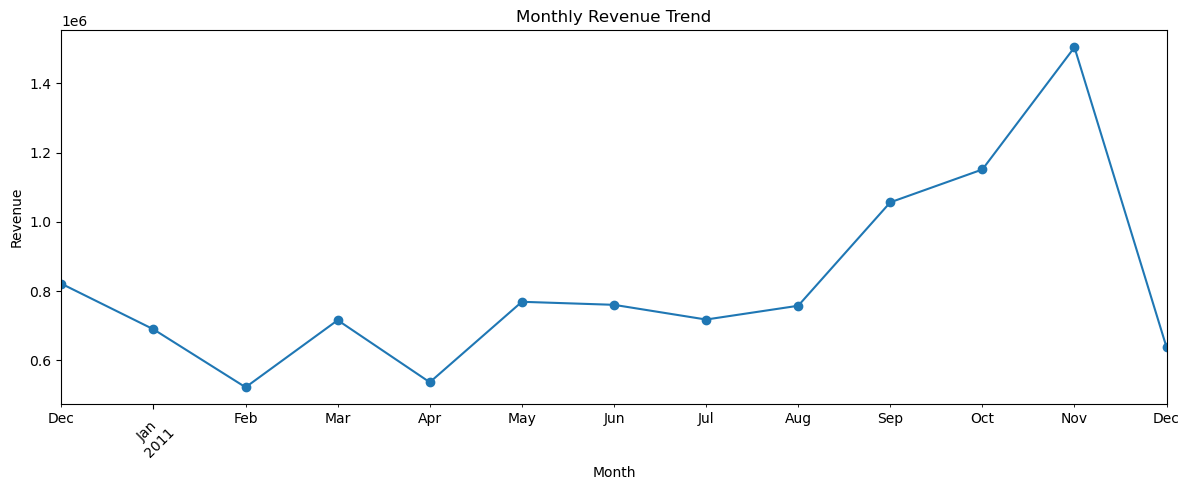

In [75]:
plt.figure(figsize=(12,5))

monthly_revenue.plot(kind="line", marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top 10 Countries

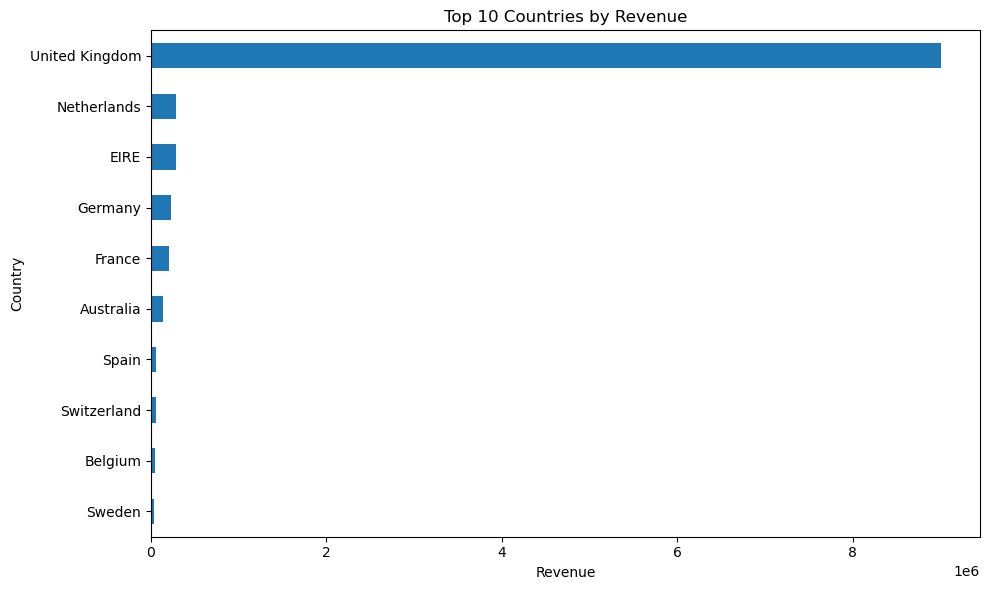

In [76]:
plt.figure(figsize=(10,6))

country_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

## Top 10 Products

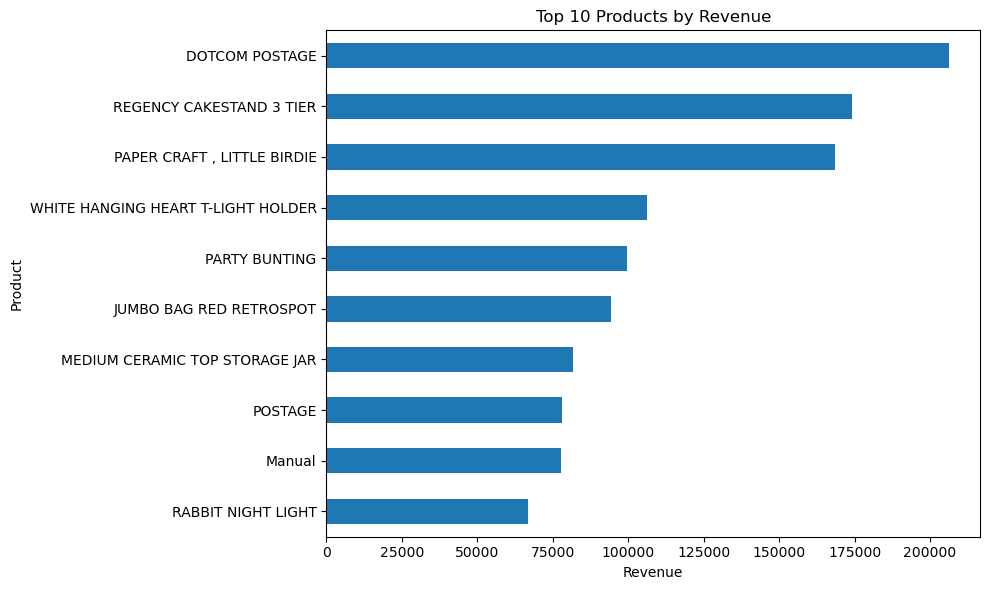

In [77]:
plt.figure(figsize=(10,6))

product_revenue.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## Revenue Distribution

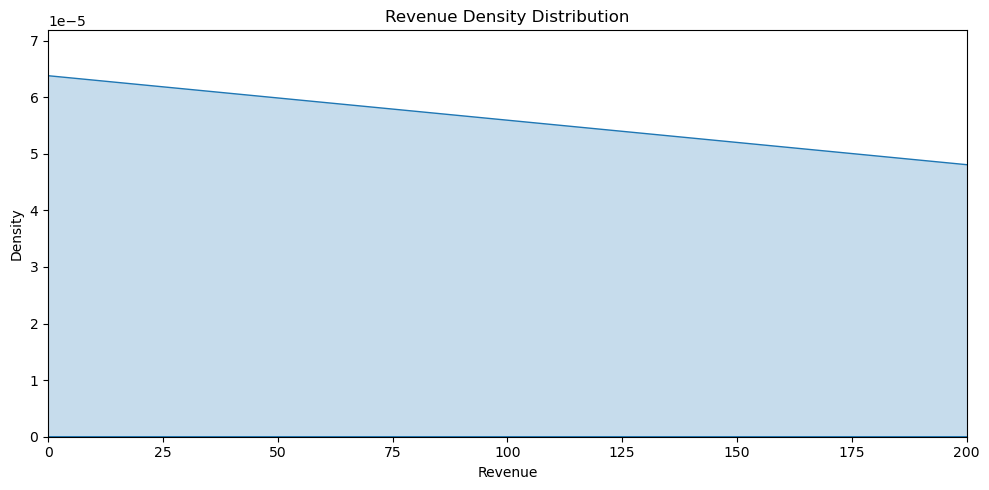

In [82]:
plt.figure(figsize=(10,5))

sns.kdeplot(sales_df["Revenue"], fill=True)

plt.title("Revenue Density Distribution")
plt.xlabel("Revenue")
plt.xlim(0, 200)

plt.tight_layout()
plt.show()

## Business Insights

1. The United Kingdom is the dominant market, generating the highest revenue and order volume among all countries.

2. The Netherlands and Singapore show high Average Order Value (AOV), indicating relatively high-value transactions despite lower order volumes compared with the United Kingdom.

3. Revenue distribution is highly right-skewed because of a small number of extremely large transactions.

4. A small number of products contribute significantly to overall revenue, highlighting the importance of identifying and monitoring top-performing products.

5. Customer-level analysis helps identify high-value customers who contribute disproportionately to total revenue.

6. Monthly revenue analysis reveals variations in sales performance across different periods and helps identify peak and low-performing months.

7. Negative-quantity transactions were investigated separately because they may represent returns or cancellations rather than normal sales.

8. The analysis shows that revenue, order volume, customer behavior, and product performance should be considered together when evaluating business performance.

## Business Recommendations

1. The business should prioritize customer retention and growth strategies in the United Kingdom because it is the strongest revenue-generating market.

2. High-AOV but lower-volume markets such as Singapore and the Netherlands should be investigated for targeted expansion opportunities.

3. Top-performing products should be monitored regularly to maintain availability and avoid stock-related revenue losses.

4. High-value customers should be targeted with personalized offers and loyalty strategies to improve retention and repeat purchases.

5. Large transactions and extreme values should be monitored separately so that they do not distort regular sales performance metrics.

6. Return and cancellation patterns should be monitored to identify products or markets with unusually high return activity.

7. Monthly sales trends should be used for inventory planning, promotional campaigns, and resource allocation.

## Conclusion

This project analyzed an Online Retail dataset using Python, Pandas, NumPy, Matplotlib, and Seaborn.

The analysis covered data cleaning, missing-value investigation, duplicate removal, date conversion, negative transaction investigation, feature engineering, descriptive statistics, outlier analysis, customer analysis, product analysis, country-level performance, and monthly sales trends.

A Revenue feature was created using Quantity × UnitPrice to support business-level analysis.

The analysis identified the United Kingdom as the strongest market by revenue and order volume, while some smaller markets demonstrated higher Average Order Values.

Overall, the project demonstrates an end-to-end data analytics workflow, from raw data cleaning and exploratory analysis to business insights and actionable recommendations.

In [85]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\Palak Jain
['.anaconda', '.android', '.conda', '.condarc', '.continuum', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '.vscode', 'anaconda3', 'AppData', 'apple_products_100k.csv', 'Application Data', 'class sep21.ipynb', 'Contacts', 'Cookies', 'CrossDevice', 'Documents', 'Downloads', 'Ecommerce_Customer_Sales_Analysis.ipynb', 'Favorites', 'iphone analysis project.ipynb', 'ipl analysis.ipynb', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'notes part2.ipynb', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{01277b4e-650e-11ef-891d-9cda3ed3f2fc}.TM.blf', 'NTUSER.DAT{01277b4e-650e-11ef-891d-9cda3ed3f2fc}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{01277b4e-650e-11ef-891d-9cda3ed3f2fc}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'online+retail.zip', 'PrintHood', 'python notes', 'python notes .ipynb', 'python notes part 2', 'python project 1', 'Recent', 'Saved Games', 'Searches', 'S